# ETA Prediction — Random Forest (v3)
Mejoras basadas en:
- Li (2017) *Predicting MTA Bus Arrival Times in NYC* — Stanford CS229
- Liu et al. (2021) *A comparative study of ML methods for bus arrival time prediction* — Expert Systems with Applications
- AlKheder et al. (2022) *Bus arrival time prediction using ML and GIS*
- Rodriguez-Sanz et al. (2022) *ML Models for Passenger Flow Prediction* — Sensors

**Cambios v2 → v3:**
- CELDA 2: imports adicionales (LabelEncoder)
- CELDA 5: agrega ScheduledArrivalTime y PublishedLineName a dropna
- CELDA 10: +schedule_delay, +line_enc, +dist_to_destination_m, +encoding cíclico, +speed_roll3, is_rush_hour separado en am/pm
- CELDA 11: features list actualizada (14 features)
- CELDA 18: grid search de hiperparámetros + mejor configuración
- CELDA 20: comparación v1/v2/v3
- CELDA 22: guarda modelo v3


In [1]:
# ── CELDA 1: sin cambios ─────────────────────────────────────────────────────
# unzip ETA dataset
!unzip "/content/drive/MyDrive/Capstone/Datasets/mta_1706.csv.zip" -d "/content/drive/MyDrive/Capstone/Datasets/ETA/"

unzip:  cannot find or open /content/drive/MyDrive/Capstone/Datasets/mta_1706.csv.zip, /content/drive/MyDrive/Capstone/Datasets/mta_1706.csv.zip.zip or /content/drive/MyDrive/Capstone/Datasets/mta_1706.csv.zip.ZIP.


In [2]:
# ── CELDA 2: MODIFICADA v3 — imports adicionales ─────────────────────────────
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder          # NUEVO v3: para line_enc

print("Librerías cargadas.")


Librerías cargadas.


In [3]:
# ── CELDA 3: sin cambios ─────────────────────────────────────────────────────
path_csv = "/Users/jazgonzalez/Documents/capstone/bus-prediction-system/ml/eta/data/mta_1706.csv"

print("Cargando dataset...")
df = pd.read_csv(path_csv, on_bad_lines='skip', low_memory=False)
print("¡Dataset cargado exitosamente!")
print(df.head())

Cargando dataset...
¡Dataset cargado exitosamente!
        RecordedAtTime  DirectionRef PublishedLineName  \
0  2017-06-01 00:03:34             0                B8   
1  2017-06-01 00:03:43             1               S61   
2  2017-06-01 00:03:49             0              Bx10   
3  2017-06-01 00:03:31             0                Q5   
4  2017-06-01 00:03:22             1               Bx1   

                  OriginName  OriginLat  OriginLong  \
0                 4 AV/95 ST  40.616104  -74.031143   
1  ST GEORGE FERRY/S61 & S91  40.643169  -74.073494   
2     E 206 ST/BAINBRIDGE AV  40.875008  -73.880142   
3           TEARDROP/LAYOVER  40.701748  -73.802399   
4      RIVERDALE AV/W 231 ST  40.881187  -73.909340   

                   DestinationName  DestinationLat  DestinationLong  \
0          BROWNSVILLE ROCKAWAY AV       40.656048       -73.907379   
1                S I MALL YUKON AV       40.575935       -74.167686   
2                 RIVERDALE 263 ST       40.912376      

In [4]:
# ── CELDA 4: sin cambios ─────────────────────────────────────────────────────
print("Tomando muestra de 3,000,000 filas...")
df_sample = df.sample(n=3000000, random_state=42)
print("Muestra tomada.")
df_sample.head()

Tomando muestra de 3,000,000 filas...
Muestra tomada.


,RecordedAtTime,DirectionRef,PublishedLineName,OriginName,OriginLat,OriginLong,DestinationName,DestinationLat,DestinationLong,VehicleRef,VehicleLocation.Latitude,VehicleLocation.Longitude,NextStopPointName,ArrivalProximityText,DistanceFromStop,ExpectedArrivalTime,ScheduledArrivalTime
2170987,2017-06-10 16:09:29,0,B35,CHURCH AV/MC DONALD AV,40.642651,-73.979584,BROWNSVILLE M GASTON BL via CHURCH,40.656345,-73.907188,NYCT_327,40.645069,-73.974039,CHURCH AV/OCEAN PY,at stop,2.0,2017-06-10 16:09:48,16:08:17
5287764,2017-06-24 17:02:27,1,M15-SBS,E 126 ST/2 AV,40.803230,-73.932449,SELECT BUS SERVICE SOUTH FERRY via 2 AV,40.702122,-74.013664,NYCT_1268,40.740819,-73.978765,2 AV/E 23 ST,< 1 stop away,420.0,2017-06-24 17:05:00,16:47:57
4304178,2017-06-20 14:45:31,0,Bx3,BROADWAY/179 ST,40.849327,-73.936508,RIVERDALE BWAY - 238 ST,40.885086,-73.900436,NYCT_4372,40.856785,-73.909881,UNIVERSITY AV/W 181 ST,approaching,79.0,2017-06-20 14:46:03,14:33:37
1255600,2017-06-06 17:42:56,1,B52,PALMETTO ST/ST NICHOLAS AV,40.700420,-73.909996,DNTWN BKLYN TILLARY ST via GATES,40.693939,-73.990311,NYCT_4528,40.700726,-73.910135,GATES AV/WYCKOFF AV,< 1 stop away,202.0,NaN,17:49:48
1135968,2017-06-06 09:22:54,0,Q88,92 ST/59 AV,40.734272,-73.869301,QUEENS VILL JAMAICA AV,40.717922,-73.736382,NYCT_6889,40.740524,-73.786886,188 ST/HORACE HARDING EXP,approaching,58.0,2017-06-06 09:23:18,08:54:35


In [5]:
# ── CELDA 5: MODIFICADA v3 — más columnas críticas ───────────────────────────
# NUEVO v3: agregamos ScheduledArrivalTime y PublishedLineName

print("Eliminando filas con valores nulos en columnas clave...")
df_processed = df_sample.dropna(subset=[
    'ExpectedArrivalTime',
    'RecordedAtTime',
    'DistanceFromStop',
    'VehicleLocation.Latitude',
    'VehicleLocation.Longitude',
    'VehicleRef',
    'ArrivalProximityText',
    'ScheduledArrivalTime',       # NUEVO v3: para schedule_delay (Liu 2021)
    'PublishedLineName',           # NUEVO v3: para line_enc (AlKheder 2022)
    'DestinationLat',              # NUEVO v3: para dist_to_destination_m
    'DestinationLong',             # NUEVO v3: para dist_to_destination_m
]).copy()

print(f"Filas después de limpiar nulos: {len(df_processed)}")
df_processed.head()


Eliminando filas con valores nulos en columnas clave...
Filas después de limpiar nulos: 2586708


,RecordedAtTime,DirectionRef,PublishedLineName,OriginName,OriginLat,OriginLong,DestinationName,DestinationLat,DestinationLong,VehicleRef,VehicleLocation.Latitude,VehicleLocation.Longitude,NextStopPointName,ArrivalProximityText,DistanceFromStop,ExpectedArrivalTime,ScheduledArrivalTime
2170987,2017-06-10 16:09:29,0,B35,CHURCH AV/MC DONALD AV,40.642651,-73.979584,BROWNSVILLE M GASTON BL via CHURCH,40.656345,-73.907188,NYCT_327,40.645069,-73.974039,CHURCH AV/OCEAN PY,at stop,2.0,2017-06-10 16:09:48,16:08:17
5287764,2017-06-24 17:02:27,1,M15-SBS,E 126 ST/2 AV,40.803230,-73.932449,SELECT BUS SERVICE SOUTH FERRY via 2 AV,40.702122,-74.013664,NYCT_1268,40.740819,-73.978765,2 AV/E 23 ST,< 1 stop away,420.0,2017-06-24 17:05:00,16:47:57
4304178,2017-06-20 14:45:31,0,Bx3,BROADWAY/179 ST,40.849327,-73.936508,RIVERDALE BWAY - 238 ST,40.885086,-73.900436,NYCT_4372,40.856785,-73.909881,UNIVERSITY AV/W 181 ST,approaching,79.0,2017-06-20 14:46:03,14:33:37
1135968,2017-06-06 09:22:54,0,Q88,92 ST/59 AV,40.734272,-73.869301,QUEENS VILL JAMAICA AV,40.717922,-73.736382,NYCT_6889,40.740524,-73.786886,188 ST/HORACE HARDING EXP,approaching,58.0,2017-06-06 09:23:18,08:54:35
1282111,2017-06-06 19:22:57,0,M7,AV OF THE AMERICAS/W 14 ST,40.737930,-73.996346,HARLEM 147 ST via 6 AV via AMSTERDAM,40.821110,-73.935898,NYCT_6759,40.781203,-73.979741,AMSTERDAM AV/W 77 ST,approaching,113.0,2017-06-06 19:23:40,19:02:37


In [6]:
# ── CELDA 6: sin cambios ─────────────────────────────────────────────────────
print("Convirtiendo columnas de tiempo...")
df_processed['ExpectedArrivalTime'] = pd.to_datetime(df_processed['ExpectedArrivalTime'])
df_processed['RecordedAtTime']      = pd.to_datetime(df_processed['RecordedAtTime'])

Convirtiendo columnas de tiempo...


In [7]:
#imprimir para ver como quedaron las fechas/horas de las columnas
print(df_processed.head())

             RecordedAtTime  DirectionRef PublishedLineName  \
2170987 2017-06-10 16:09:29             0               B35   
5287764 2017-06-24 17:02:27             1           M15-SBS   
4304178 2017-06-20 14:45:31             0               Bx3   
1135968 2017-06-06 09:22:54             0               Q88   
1282111 2017-06-06 19:22:57             0                M7   

                         OriginName  OriginLat  OriginLong  \
2170987      CHURCH AV/MC DONALD AV  40.642651  -73.979584   
5287764               E 126 ST/2 AV  40.803230  -73.932449   
4304178             BROADWAY/179 ST  40.849327  -73.936508   
1135968                 92 ST/59 AV  40.734272  -73.869301   
1282111  AV OF THE AMERICAS/W 14 ST  40.737930  -73.996346   

                                 DestinationName  DestinationLat  \
2170987       BROWNSVILLE M GASTON BL via CHURCH       40.656345   
5287764  SELECT BUS SERVICE SOUTH FERRY via 2 AV       40.702122   
4304178                  RIVERDALE BWAY - 23

In [8]:
# ── CELDA 7: sin cambios ─────────────────────────────────────────────────────
print("Creando el target (y) 'TimeToArrival' (en minutos)...")
df_processed['TimeToArrival'] = (
    df_processed['ExpectedArrivalTime'] - df_processed['RecordedAtTime']
).dt.total_seconds() / 60
df_processed.head()

Creando el target (y) 'TimeToArrival' (en minutos)...


,RecordedAtTime,DirectionRef,PublishedLineName,OriginName,OriginLat,OriginLong,DestinationName,DestinationLat,DestinationLong,VehicleRef,VehicleLocation.Latitude,VehicleLocation.Longitude,NextStopPointName,ArrivalProximityText,DistanceFromStop,ExpectedArrivalTime,ScheduledArrivalTime,TimeToArrival
2170987,2017-06-10 16:09:29,0,B35,CHURCH AV/MC DONALD AV,40.642651,-73.979584,BROWNSVILLE M GASTON BL via CHURCH,40.656345,-73.907188,NYCT_327,40.645069,-73.974039,CHURCH AV/OCEAN PY,at stop,2.0,2017-06-10 16:09:48,16:08:17,0.316667
5287764,2017-06-24 17:02:27,1,M15-SBS,E 126 ST/2 AV,40.803230,-73.932449,SELECT BUS SERVICE SOUTH FERRY via 2 AV,40.702122,-74.013664,NYCT_1268,40.740819,-73.978765,2 AV/E 23 ST,< 1 stop away,420.0,2017-06-24 17:05:00,16:47:57,2.550000
4304178,2017-06-20 14:45:31,0,Bx3,BROADWAY/179 ST,40.849327,-73.936508,RIVERDALE BWAY - 238 ST,40.885086,-73.900436,NYCT_4372,40.856785,-73.909881,UNIVERSITY AV/W 181 ST,approaching,79.0,2017-06-20 14:46:03,14:33:37,0.533333
1135968,2017-06-06 09:22:54,0,Q88,92 ST/59 AV,40.734272,-73.869301,QUEENS VILL JAMAICA AV,40.717922,-73.736382,NYCT_6889,40.740524,-73.786886,188 ST/HORACE HARDING EXP,approaching,58.0,2017-06-06 09:23:18,08:54:35,0.400000
1282111,2017-06-06 19:22:57,0,M7,AV OF THE AMERICAS/W 14 ST,40.737930,-73.996346,HARLEM 147 ST via 6 AV via AMSTERDAM,40.821110,-73.935898,NYCT_6759,40.781203,-73.979741,AMSTERDAM AV/W 77 ST,approaching,113.0,2017-06-06 19:23:40,19:02:37,0.716667


In [9]:
# ── CELDA 8: sin cambios ─────────────────────────────────────────────────────
print("Limpiando el target...")
rows_before = len(df_processed)
df_processed = df_processed[df_processed['TimeToArrival'] > 0]
print(f"Filas eliminadas (tiempo negativo): {rows_before - len(df_processed)}")

Limpiando el target...
Filas eliminadas (tiempo negativo): 1336


In [10]:
# ── CELDA 9: sin cambios ─────────────────────────────────────────────────────
rows_before = len(df_processed)
df_processed = df_processed[df_processed['TimeToArrival'] < 60]
print(f"Filas eliminadas (outliers > 1 hora): {rows_before - len(df_processed)}")

Filas eliminadas (outliers > 1 hora): 0


In [11]:
# ── CELDA 10: MODIFICADA v3 — feature engineering ampliado ──────────────────
#
# FEATURES v2:
#   DistanceFromStop, speed_kmh, proximity_enc, distance_close, direction
#
# FEATURES NUEVAS EN v3:
#   schedule_delay, line_enc, dist_to_dest_m,
#   hour_sin/cos, dow_sin/cos, speed_roll3, is_am_rush, is_pm_rush

print("Creando features...")

# ── Features de tiempo base ───────────────────────────────────────────────────
df_processed['month']       = df_processed['RecordedAtTime'].dt.month
df_processed['day']         = df_processed['RecordedAtTime'].dt.day
df_processed['day_of_week'] = df_processed['RecordedAtTime'].dt.dayofweek
df_processed['hour']        = df_processed['RecordedAtTime'].dt.hour
df_processed['minute']      = df_processed['RecordedAtTime'].dt.minute

# ── v3-1: schedule_delay ─────────────────────────────────────────────────────
# Fuente: Liu et al. (2021) — schedule deviation es uno de los predictores más
# importantes. Captura si el bus va tarde/adelantado respecto al horario programado.
# ScheduledArrivalTime en el MTA puede tener formato '24:06:14' (hora >= 24).
print("  Calculando schedule_delay...")

def parse_mta_scheduled(base_dt, t):
    try:
        h, m, s = t.split(':')
        h = int(h) % 24
        return base_dt.replace(hour=h, minute=int(m), second=int(s))
    except:
        return None

df_processed['sched_parsed'] = df_processed.apply(
    lambda r: parse_mta_scheduled(r['ExpectedArrivalTime'], r['ScheduledArrivalTime']),
    axis=1
)
df_processed['schedule_delay'] = (
    df_processed['ExpectedArrivalTime'] - df_processed['sched_parsed']
).dt.total_seconds() / 60
df_processed['schedule_delay'] = df_processed['schedule_delay'].clip(-30, 60).fillna(0)
df_processed = df_processed.drop(columns=['sched_parsed'])
print(f"  ✓ schedule_delay (mediana: {df_processed['schedule_delay'].median():.2f} min)")

# ── v3-2: line_enc ───────────────────────────────────────────────────────────
# Fuente: AlKheder et al. (2022) — distintas líneas tienen tiempos estructuralmente
# diferentes por densidad de paradas y longitud de ruta.
le_line = LabelEncoder()
df_processed['line_enc'] = le_line.fit_transform(
    df_processed['PublishedLineName'].astype(str)
)
print(f"  ✓ line_enc ({df_processed['line_enc'].nunique()} líneas únicas)")

# ── v3-3: dist_to_dest_m ─────────────────────────────────────────────────────
# Fuente: AlKheder et al. (2022) — distingue distancia al próximo stop vs
# distancia al destino final del viaje.
print("  Calculando dist_to_dest_m...")
R = 6371000
phi1_d = np.radians(df_processed['VehicleLocation.Latitude'].values)
phi2_d = np.radians(df_processed['DestinationLat'].values)
dphi_d = phi2_d - phi1_d
dlambda_d = np.radians(
    df_processed['DestinationLong'].values - df_processed['VehicleLocation.Longitude'].values
)
a_dest = np.sin(dphi_d/2)**2 + np.cos(phi1_d) * np.cos(phi2_d) * np.sin(dlambda_d/2)**2
df_processed['dist_to_dest_m'] = R * 2 * np.arctan2(np.sqrt(a_dest), np.sqrt(1 - a_dest))
print(f"  ✓ dist_to_dest_m (mediana: {df_processed['dist_to_dest_m'].median():.0f} m)")

# ── v3-4: encoding cíclico ───────────────────────────────────────────────────
# Fuente: Rodriguez-Sanz et al. (2022) — hora 23 y hora 0 son contiguas;
# sin/cos preserva esa continuidad circular.
df_processed['hour_sin'] = np.sin(2 * np.pi * df_processed['hour'] / 24)
df_processed['hour_cos'] = np.cos(2 * np.pi * df_processed['hour'] / 24)
df_processed['dow_sin']  = np.sin(2 * np.pi * df_processed['day_of_week'] / 7)
df_processed['dow_cos']  = np.cos(2 * np.pi * df_processed['day_of_week'] / 7)
print("  ✓ hour_sin, hour_cos, dow_sin, dow_cos")

# ── v3-5: is_am_rush / is_pm_rush ────────────────────────────────────────────
# Fuente: Li (2017) + mae_por_hora.csv propio — peor MAE observado en 16-18h,
# se separa en dos flags en lugar de un único is_rush_hour.
df_processed['is_am_rush'] = df_processed['hour'].isin([7, 8, 9]).astype(int)
df_processed['is_pm_rush'] = df_processed['hour'].isin([16, 17, 18]).astype(int)
print("  ✓ is_am_rush, is_pm_rush")

# ── v2: distance_close, direction, proximity_enc ─────────────────────────────
df_processed['distance_close'] = (df_processed['DistanceFromStop'] < 300).astype(int)
df_processed['direction']      = df_processed['DirectionRef'].astype(int)

prox_map = {'approaching': 0, 'at stop': 0, '< 1 stop away': 1}
df_processed['proximity_enc'] = df_processed['ArrivalProximityText'].map(prox_map)
mask_null = df_processed['proximity_enc'].isnull()
df_processed.loc[mask_null, 'proximity_enc'] = (
    df_processed.loc[mask_null, 'ArrivalProximityText']
    .str.extract(r'([\d.]+)')[0].astype(float)
)
df_processed['proximity_enc'] = df_processed['proximity_enc'].fillna(
    df_processed['proximity_enc'].median()
)
print("  ✓ distance_close, direction, proximity_enc")

# ── v2: speed_kmh (Haversine entre posiciones GPS consecutivas) ───────────────
# Fuente: AlKheder (2022) — velocidad actual del bus.
# IMPORTANTE: ordenar por VehicleRef + RecordedAtTime antes del shift().
print("  Calculando speed_kmh (puede tardar ~1 min con 3M filas)...")

df_processed = df_processed.sort_values(
    ['VehicleRef', 'RecordedAtTime']
).reset_index(drop=True)

df_processed['prev_lat']  = df_processed.groupby('VehicleRef')['VehicleLocation.Latitude'].shift(1)
df_processed['prev_lon']  = df_processed.groupby('VehicleRef')['VehicleLocation.Longitude'].shift(1)
df_processed['prev_time'] = df_processed.groupby('VehicleRef')['RecordedAtTime'].shift(1)

valid = df_processed['prev_lat'].notna()
phi1 = np.radians(df_processed.loc[valid, 'prev_lat'].values)
phi2 = np.radians(df_processed.loc[valid, 'VehicleLocation.Latitude'].values)
dphi = np.radians(
    df_processed.loc[valid, 'VehicleLocation.Latitude'].values -
    df_processed.loc[valid, 'prev_lat'].values
)
dlambda = np.radians(
    df_processed.loc[valid, 'VehicleLocation.Longitude'].values -
    df_processed.loc[valid, 'prev_lon'].values
)
a = np.sin(dphi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda/2)**2
dist_m = R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

time_s = (
    df_processed.loc[valid, 'RecordedAtTime'] -
    df_processed.loc[valid, 'prev_time']
).dt.total_seconds().values

speed = np.where(time_s > 0, (dist_m / time_s) * 3.6, np.nan)
df_processed.loc[valid, 'speed_kmh'] = speed
df_processed['speed_kmh'] = df_processed['speed_kmh'].clip(0, 60)
median_speed = df_processed['speed_kmh'].median()
df_processed['speed_kmh'] = df_processed['speed_kmh'].fillna(median_speed)
df_processed = df_processed.drop(columns=['prev_lat', 'prev_lon', 'prev_time'])
print(f"  ✓ speed_kmh (mediana: {median_speed:.1f} km/h)")

# ── v3-6: speed_roll3 — VA DESPUÉS de speed_kmh ──────────────────────────────
# Fuente: AlKheder et al. (2022) — media móvil de los últimos 3 registros.
# DEBE calcularse después de speed_kmh; usa la misma columna como input.
df_processed['speed_roll3'] = (
    df_processed.groupby('VehicleRef')['speed_kmh']
    .transform(lambda x: x.rolling(3, min_periods=1).mean())
)
print(f"  ✓ speed_roll3 (mediana: {df_processed['speed_roll3'].median():.1f} km/h)")

print(f"\n✓ Feature engineering v3 completo")
df_processed[['DistanceFromStop', 'schedule_delay', 'speed_kmh', 'speed_roll3',
              'line_enc', 'dist_to_dest_m', 'hour_sin', 'hour_cos',
              'is_am_rush', 'is_pm_rush', 'TimeToArrival']].head()


Creando features...
  Calculando schedule_delay...
  ✓ schedule_delay (mediana: 3.08 min)
  ✓ line_enc (236 líneas únicas)
  Calculando dist_to_dest_m...
  ✓ dist_to_dest_m (mediana: 3768 m)
  ✓ hour_sin, hour_cos, dow_sin, dow_cos
  ✓ is_am_rush, is_pm_rush
  ✓ distance_close, direction, proximity_enc
  Calculando speed_kmh (puede tardar ~1 min con 3M filas)...


/var/folders/zy/40s49jyj3qn6fml64xdx7_jh0000gn/T/ipykernel_55737/616675047.py:132: RuntimeWarning: invalid value encountered in divide
  speed = np.where(time_s > 0, (dist_m / time_s) * 3.6, np.nan)


  ✓ speed_kmh (mediana: 6.7 km/h)
  ✓ speed_roll3 (mediana: 6.7 km/h)

✓ Feature engineering v3 completo


,DistanceFromStop,schedule_delay,speed_kmh,speed_roll3,line_enc,dist_to_dest_m,hour_sin,hour_cos,is_am_rush,is_pm_rush,TimeToArrival
0,13.0,-0.133333,6.723891,6.723891,65,8644.017650,1.0,6.123234e-17,0,0,0.250000
1,16.0,-0.333333,10.985444,8.854668,65,6864.131664,1.0,6.123234e-17,0,0,0.166667
2,384.0,-0.100000,12.377357,10.028897,65,4715.071027,1.0,6.123234e-17,0,0,1.566667
3,16.0,-0.433333,12.561962,11.974921,65,2748.412869,1.0,6.123234e-17,0,0,0.283333
4,197.0,2.916667,7.703318,10.880879,65,151.289485,1.0,6.123234e-17,0,0,0.983333


In [12]:
# ── CELDA 11: MODIFICADA v3 — lista de features actualizada ──────────────────
print("Seleccionando columnas finales para el modelo...")

# v1 (6 features): DistanceFromStop, month, day, day_of_week, hour, minute
# v2 (10 features): +speed_kmh, +proximity_enc, +distance_close, +direction, +is_rush_hour
# v3 (14 features): +schedule_delay, +line_enc, +dist_to_dest_m, +encoding cíclico,
#                   +speed_roll3, is_rush_hour → is_am_rush + is_pm_rush

features = [
    # ── Distancia (dominante) ────────────────────────────────────────────────
    'DistanceFromStop',      # 91.7% importancia en v2 (Li 2017)
    'dist_to_dest_m',        # distancia al destino final (AlKheder 2022) — NUEVO v3
    'distance_close',        # flag <300m (Li 2017)
    # ── Schedule ────────────────────────────────────────────────────────────
    'schedule_delay',        # retraso vs horario programado (Liu 2021) — NUEVO v3
    # ── Velocidad ────────────────────────────────────────────────────────────
    'speed_kmh',             # velocidad puntual (AlKheder 2022)
    'speed_roll3',           # media móvil vel. últimos 3 registros (AlKheder 2022) — NUEVO v3
    # ── Ruta ─────────────────────────────────────────────────────────────────
    'line_enc',              # línea de bus (AlKheder 2022) — NUEVO v3
    'direction',             # dirección de la ruta (ETA Survey 2019)
    # ── Tiempo cíclico ───────────────────────────────────────────────────────
    'hour_sin',              # encoding cíclico hora (Rodriguez-Sanz 2022) — NUEVO v3
    'hour_cos',              # encoding cíclico hora (Rodriguez-Sanz 2022) — NUEVO v3
    'dow_sin',               # encoding cíclico día semana (Rodriguez-Sanz 2022) — NUEVO v3
    'dow_cos',               # encoding cíclico día semana (Rodriguez-Sanz 2022) — NUEVO v3
    # ── Rush hour (separado con datos reales) ────────────────────────────────
    'is_am_rush',            # rush AM: 7-9h (Li 2017 + mae_por_hora.csv)
    'is_pm_rush',            # rush PM: 16-18h (peor MAE observado en datos reales)
    # ── Proximidad ───────────────────────────────────────────────────────────
    'proximity_enc',         # texto proximidad MTA → número (Li 2017)
    # ── Tiempo (raw, mantenido para compatibilidad) ───────────────────────────
    'minute',
    'day',
]

target = 'TimeToArrival'

print(f"Total features: {len(features)}")
for f in features:
    print(f"  - {f}")


Seleccionando columnas finales para el modelo...
Total features: 17
  - DistanceFromStop
  - dist_to_dest_m
  - distance_close
  - schedule_delay
  - speed_kmh
  - speed_roll3
  - line_enc
  - direction
  - hour_sin
  - hour_cos
  - dow_sin
  - dow_cos
  - is_am_rush
  - is_pm_rush
  - proximity_enc
  - minute
  - day


In [13]:
# ── CELDA 12: sin cambios (adaptado) ─────────────────────────────────────────
df_final = df_processed[features + [target]].dropna()

print(f"\n--- Preprocesamiento completado ---")
print(f"Total de filas listas para entrenar: {len(df_final):,}")
print(df_final.head())


--- Preprocesamiento completado ---
Total de filas listas para entrenar: 2,585,372
   DistanceFromStop  dist_to_dest_m  distance_close  schedule_delay  \
0              13.0     8644.017650               1       -0.133333   
1              16.0     6864.131664               1       -0.333333   
2             384.0     4715.071027               0       -0.100000   
3              16.0     2748.412869               1       -0.433333   
4             197.0      151.289485               1        2.916667   

   speed_kmh  speed_roll3  line_enc  direction  hour_sin      hour_cos  \
0   6.723891     6.723891        65          1       1.0  6.123234e-17   
1  10.985444     8.854668        65          1       1.0  6.123234e-17   
2  12.377357    10.028897        65          1       1.0  6.123234e-17   
3  12.561962    11.974921        65          1       1.0  6.123234e-17   
4   7.703318    10.880879        65          1       1.0  6.123234e-17   

    dow_sin   dow_cos  is_am_rush  is_pm_rus

In [14]:
# ── CELDA 13: sin cambios ─────────────────────────────────────────────────────
ruta_salida = "/Users/jazgonzalez/Documents/capstone/bus-prediction-system/ml/eta/data/eta_preprocessedfinal.csv"
df_final.to_csv(ruta_salida, index=False)
print(f"Datos guardados en: {ruta_salida}")

Datos guardados en: /Users/jazgonzalez/Documents/capstone/bus-prediction-system/ml/eta/data/eta_preprocessedfinal.csv


In [15]:
# ── CELDA 14: sin cambios ─────────────────────────────────────────────────────
print("\nValores nulos restantes (deben ser 0):")
print(df_final.isnull().sum())
print(f"\nTamaño del dataset limpio: {df_final.shape}")


Valores nulos restantes (deben ser 0):
DistanceFromStop    0
dist_to_dest_m      0
distance_close      0
schedule_delay      0
speed_kmh           0
speed_roll3         0
line_enc            0
direction           0
hour_sin            0
hour_cos            0
dow_sin             0
dow_cos             0
is_am_rush          0
is_pm_rush          0
proximity_enc       0
minute              0
day                 0
TimeToArrival       0
dtype: int64

Tamaño del dataset limpio: (2585372, 18)


In [16]:
# ── CELDA 15: sin cambios ─────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

In [17]:
# ── CELDA 16: sin cambios ─────────────────────────────────────────────────────
X = df_final[features]
y = df_final[target]
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (2585372, 17)
y shape: (2585372,)


In [18]:
# ── CELDA 17: sin cambios ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape[0]:,} filas")
print(f"Test:  {X_test.shape[0]:,} filas")

Train: 2,068,297 filas
Test:  517,075 filas


In [19]:
#buscar la mejor configuracion del modelo con solo una muestra de los datos para ahorrar tiempo
#para luego entrenar el modelo final con la configuración óptima usando todo el dataset
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
import time

# Modelo base
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_leaf': [1, 3, 5],
    'max_features': ['sqrt', 0.5]
}

t0 = time.time()

search = RandomizedSearchCV(
    rf,
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42
)

# Muestra para búsqueda, probar primero con 100k y luego ver para aumentar
X_search = X_train.sample(
    n=min(100000, len(X_train)),
    random_state=42
)

y_search = y_train.loc[X_search.index]

search.fit(X_search, y_search)

print("Best params:", search.best_params_)
print(f"Tiempo búsqueda: {(time.time()-t0)/60:.2f} min")

/Users/jazgonzalez/Documents/capstone/bus-prediction-system/.venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'n_estimators': 300, 'min_samples_leaf': 3, 'max_features': 0.5, 'max_depth': 20}
Tiempo búsqueda: 4.09 min


In [20]:
#entrenar el modelo final con la configuración óptima usando todo el dataset
best_params = search.best_params_

rf_model = RandomForestRegressor(
    **best_params,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.5
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [25]:
# ── CELDA 19: sin cambios ─────────────────────────────────────────────────────
y_pred = rf_model.predict(X_test)

print("--- Comparación de Predicción vs. Real (primeras 10) ---")
for i in range(10):
    print(f"Predicción: {y_pred[i]:.2f}   |  Valor Real: {y_test.iloc[i]:.2f}")

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2   = r2_score(y_test, y_pred)

--- Comparación de Predicción vs. Real (primeras 10) ---
Predicción: 0.56   |  Valor Real: 0.72
Predicción: 0.94   |  Valor Real: 0.88
Predicción: 0.56   |  Valor Real: 0.38
Predicción: 0.27   |  Valor Real: 0.17
Predicción: 0.63   |  Valor Real: 0.33
Predicción: 0.68   |  Valor Real: 0.55
Predicción: 0.28   |  Valor Real: 0.37
Predicción: 0.36   |  Valor Real: 0.38
Predicción: 0.61   |  Valor Real: 0.28
Predicción: 0.28   |  Valor Real: 0.30


In [26]:
# ── CELDA 20: MODIFICADA v3 — métricas con comparación v1/v2/v3 ─────────────
print("\n--- Métricas de Evaluación del Modelo Final ---")
print(f'Error Absoluto Medio (MAE):   {mae:.4f} min  ({mae*60:.1f} segundos)')
print(f'Error Cuadrático Medio (MSE): {mse:.4f}')
print(f'Raíz del ECM (RMSE):          {rmse:.4f} min')
print(f'Coeficiente R-cuadrado (R²):  {r2:.4f}')

# Referencia histórica
r2_v1  = 0.84;  mae_v1  = 0.35   # v1: features básicas
r2_v2  = 0.84;  mae_v2  = 0.35   # v2: +speed_kmh, proximity_enc, etc.

print(f"\n--- Comparación de versiones ---")
print(f"{'Versión':<10} {'R²':>8} {'MAE (min)':>12} {'MAE (seg)':>12}")
print("-" * 46)
print(f"{'v1':<10} {r2_v1:>8.4f} {mae_v1:>12.4f} {mae_v1*60:>12.1f}s")
print(f"{'v2':<10} {r2_v2:>8.4f} {mae_v2:>12.4f} {mae_v2*60:>12.1f}s")
print(f"{'v3 (esta)':<10} {r2:>8.4f} {mae:>12.4f} {mae*60:>12.1f}s")
print("-" * 46)
delta_r2  = r2  - r2_v2
delta_mae = mae - mae_v2
print(f"{'Δ v2→v3':<10} {delta_r2:>+8.4f} {delta_mae:>+12.4f} {delta_mae*60:>+12.1f}s")

print(f"\n--- Mejor config del grid search ---")
print(search.best_params_)



--- Métricas de Evaluación del Modelo Final ---
Error Absoluto Medio (MAE):   0.2698 min  (16.2 segundos)
Error Cuadrático Medio (MSE): 0.1953
Raíz del ECM (RMSE):          0.4420 min
Coeficiente R-cuadrado (R²):  0.9248

--- Comparación de versiones ---
Versión          R²    MAE (min)    MAE (seg)
----------------------------------------------
v1           0.8400       0.3500         21.0s
v2           0.8400       0.3500         21.0s
v3 (esta)    0.9248       0.2698         16.2s
----------------------------------------------
Δ v2→v3     +0.0848      -0.0802         -4.8s

--- Mejor config del grid search ---
{'n_estimators': 300, 'min_samples_leaf': 3, 'max_features': 0.5, 'max_depth': 20}


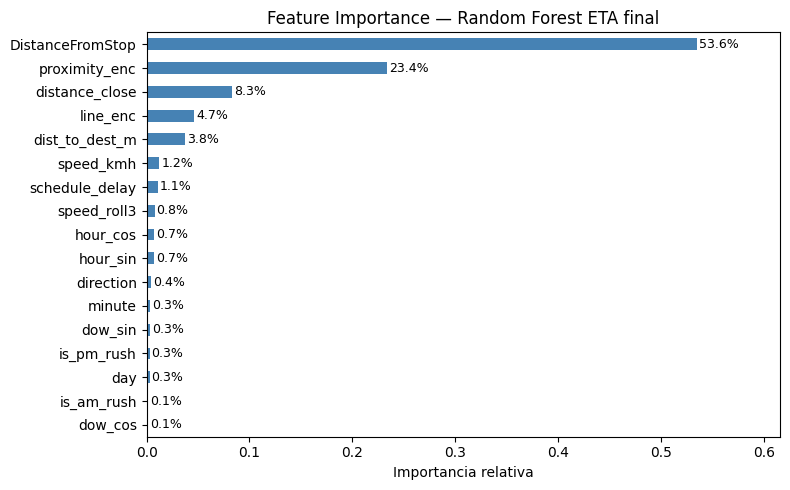

Gráfico guardado como 'feature_importance_eta_final.png'


In [27]:
# ── CELDA 21: NUEVA — feature importance (para la tesis) ─────────────────────
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(
    rf_model.feature_importances_,
    index=features
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Importancia relativa')
ax.set_title('Feature Importance — Random Forest ETA final')
ax.set_xlim(0, importances.max() * 1.15)

# Etiquetas con el porcentaje en cada barra
for i, v in enumerate(importances):
    ax.text(v + 0.002, i, f'{v*100:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance_eta_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado como 'feature_importance_eta_final.png'")

In [24]:
#usar estos datos para definir rush_hour mas arriba

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Crear DataFrame con predicciones, valores reales, y la hora de cada registro
error_analysis = pd.DataFrame({
    'y_real':    y_test.values,
    'y_pred':    y_pred,
    'hour':      X_test['hour'].values,
    'day_of_week': X_test['day_of_week'].values
})

# Error absoluto por fila
error_analysis['abs_error'] = abs(error_analysis['y_real'] - error_analysis['y_pred'])

# MAE agrupado por hora del día
mae_por_hora = error_analysis.groupby('hour')['abs_error'].mean()

# MAE agrupado por día de la semana (0=lunes, 6=domingo)
mae_por_dia = error_analysis.groupby('day_of_week')['abs_error'].mean()

print("MAE por hora del día (en minutos):")
print(mae_por_hora.round(4))

print("\nMAE por día de la semana:")
dias = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']
for i, val in mae_por_dia.items():
    print(f"  {dias[i]}: {val:.4f} min")

# Guardar para incluir en la tesis
mae_por_hora.to_csv('mae_por_hora.csv')
mae_por_dia.to_csv('mae_por_dia.csv')

KeyError: 'hour'

In [28]:
# ── CELDA 22: MODIFICADA v3 — guardar modelo ─────────────────────────────────
import joblib, pickle

model_filename   = 'rf_model_eta_final.pkl'
features_filename = 'rf_features_eta_final.pkl'

joblib.dump(rf_model, model_filename)

# Guardamos features + best_params para reproducibilidad
meta = {
    'features':    features,
    'best_params': search.best_params_,
    'mae_cv':      -search.best_score_,
}
with open(features_filename, 'wb') as f:
    pickle.dump(meta, f)

print(f"✓ Modelo guardado:   '{model_filename}'")
print(f"✓ Metadata guardada: '{features_filename}'")
print(f"\nFeatures ({len(features)}): {features}")
print(f"Best params: {search.best_params_}")


✓ Modelo guardado:   'rf_model_eta_final.pkl'
✓ Metadata guardada: 'rf_features_eta_final.pkl'

Features (17): ['DistanceFromStop', 'dist_to_dest_m', 'distance_close', 'schedule_delay', 'speed_kmh', 'speed_roll3', 'line_enc', 'direction', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_am_rush', 'is_pm_rush', 'proximity_enc', 'minute', 'day']
Best params: {'n_estimators': 300, 'min_samples_leaf': 3, 'max_features': 0.5, 'max_depth': 20}
